In [13]:
# Cell 1 — Imports & Load

import re
import numpy as np
import pandas as pd

# torch 用来做可微优化（比 scipy 数值梯度稳定很多）
import torch
import torch.nn.functional as F

from collections import defaultdict

DATA_PATH = "2026_MCM_Problem_C_Data.csv"

# reproducibility
np.random.seed(0)
torch.manual_seed(0)

df_raw = pd.read_csv(DATA_PATH)
print(df_raw.shape)
df_raw.head()


(421, 53)


,celebrity_name,ballroom_partner,celebrity_industry,celebrity_homestate,celebrity_homecountry/region,celebrity_age_during_season,season,results,placement,week1_judge1_score,...,week9_judge3_score,week9_judge4_score,week10_judge1_score,week10_judge2_score,week10_judge3_score,week10_judge4_score,week11_judge1_score,week11_judge2_score,week11_judge3_score,week11_judge4_score
0,John O'Hurley,Charlotte Jorgensen,Actor/Actress,Maine,United States,50,1,2nd Place,2,7.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Kelly Monaco,Alec Mazo,Actor/Actress,Pennsylvania,United States,29,1,1st Place,1,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Evander Holyfield,Edyta Sliwinska,Athlete,Alabama,United States,42,1,Eliminated Week 3,5,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Rachel Hunter,Jonathan Roberts,Model,NaN,New Zealand,35,1,Eliminated Week 4,4,7.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Joey McIntyre,Ashly DelGrosso,Singer/Rapper,Massachusetts,United States,32,1,3rd Place,3,7.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
# Cell 2 — Reshape wide weekly judges table -> long panel

# find all week columns like "week1_judge1_score"
week_cols = [c for c in df_raw.columns if re.match(r"week\d+_judge\d+_score", c)]
assert len(week_cols) > 0

# detect max week index from columns
week_ids = sorted({int(re.findall(r"week(\d+)_", c)[0]) for c in week_cols})
max_week_global = max(week_ids)
print("Weeks found:", week_ids)

records = []
for w in range(1, max_week_global + 1):
    cols = [f"week{w}_judge{j}_score" for j in range(1, 5)]
    if not all(c in df_raw.columns for c in cols):
        continue

    tmp = df_raw[
        [
            "season",
            "celebrity_name",
            "ballroom_partner",
            "celebrity_industry",
            "celebrity_homestate",
            "celebrity_homecountry/region",
            "celebrity_age_during_season",
            "results",
            "placement",
        ] + cols
    ].copy()

    tmp["week"] = w
    tmp["judge_total"] = tmp[cols].sum(axis=1, skipna=True)        # NaN will be ignored in sum
    tmp["judge_non_na"] = tmp[cols].notna().sum(axis=1)            # how many judge entries exist
    tmp = tmp.drop(columns=cols)
    records.append(tmp)

long = pd.concat(records, ignore_index=True)

# only keep weeks that exist in-season (judge_non_na>0)
long = long[long["judge_non_na"] > 0].copy()

print(long.shape)
long.head()


Weeks found: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
(4199, 12)


,season,celebrity_name,ballroom_partner,celebrity_industry,celebrity_homestate,celebrity_homecountry/region,celebrity_age_during_season,results,placement,week,judge_total,judge_non_na
0,1,John O'Hurley,Charlotte Jorgensen,Actor/Actress,Maine,United States,50,2nd Place,2,1,20.0,3
1,1,Kelly Monaco,Alec Mazo,Actor/Actress,Pennsylvania,United States,29,1st Place,1,1,13.0,3
2,1,Evander Holyfield,Edyta Sliwinska,Athlete,Alabama,United States,42,Eliminated Week 3,5,1,18.0,3
3,1,Rachel Hunter,Jonathan Roberts,Model,NaN,New Zealand,35,Eliminated Week 4,4,1,20.0,3
4,1,Joey McIntyre,Ashly DelGrosso,Singer/Rapper,Massachusetts,United States,32,3rd Place,3,1,20.0,3


In [15]:
# Cell 3 — Parse elimination week; build "alive set" and elimination events per (season, week)

def parse_elim_week(res):
    """Return elim week number if 'Eliminated Week X' or 'Withdrawn Week X', else None."""
    if pd.isna(res):
        return None
    s = str(res)
    m = re.search(r"Eliminated Week\s*(\d+)", s)
    if m:
        return int(m.group(1))
    m = re.search(r"Withdrawn Week\s*(\d+)", s)
    if m:
        return int(m.group(1))
    return None

meta = df_raw[
    [
        "season",
        "celebrity_name",
        "ballroom_partner",
        "celebrity_industry",
        "celebrity_homestate",
        "celebrity_homecountry/region",
        "celebrity_age_during_season",
        "results",
        "placement",
    ]
].drop_duplicates()

meta["elim_week"] = meta["results"].apply(parse_elim_week)

# max week per season
max_week_by_season = long.groupby("season")["week"].max()

# merge elim_week into long
panel = long.merge(meta[["season", "celebrity_name", "elim_week", "placement",
                         "celebrity_industry","celebrity_homestate",
                         "celebrity_homecountry/region","celebrity_age_during_season",
                         "ballroom_partner"]].drop_duplicates(),
                   on=["season","celebrity_name"], how="left")

panel["max_week"] = panel["season"].map(max_week_by_season)

# fill elim_week for finalists as max_week (they "stay alive" to the end)
panel["elim_week_filled"] = panel["elim_week"].fillna(panel["max_week"])

# alive in week t if t <= elim_week (inclusive)
panel["alive"] = panel["week"] <= panel["elim_week_filled"]

# eliminated this week: elim_week == week
panel["elim_this_week"] = panel["elim_week"].notna() & (panel["elim_week"].astype("Int64") == panel["week"])

# judge share within alive set each (season, week)
def add_j_share(dfw):
    dfw = dfw.copy()
    alive = dfw["alive"].values
    tot = dfw.loc[alive, "judge_total"].sum()
    if tot <= 0:
        dfw["judge_share"] = np.nan
    else:
        dfw["judge_share"] = np.where(alive, dfw["judge_total"] / tot, np.nan)
    return dfw

panel = panel.groupby(["season","week"], group_keys=False).apply(add_j_share)

# quick sanity
print("Seasons:", panel["season"].nunique(), "Rows:", panel.shape[0])
panel.head()


Seasons: 34 Rows: 4199


/var/folders/1q/v465hb014m30111mh0rv30rh0000gn/T/ipykernel_15863/1163435237.py:64: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  panel = panel.groupby(["season","week"], group_keys=False).apply(add_j_share)


,season,celebrity_name,ballroom_partner_x,celebrity_industry_x,celebrity_homestate_x,celebrity_homecountry/region_x,celebrity_age_during_season_x,results,placement_x,week,...,celebrity_industry_y,celebrity_homestate_y,celebrity_homecountry/region_y,celebrity_age_during_season_y,ballroom_partner_y,max_week,elim_week_filled,alive,elim_this_week,judge_share
0,1,John O'Hurley,Charlotte Jorgensen,Actor/Actress,Maine,United States,50,2nd Place,2,1,...,Actor/Actress,Maine,United States,50,Charlotte Jorgensen,6,6.0,True,False,0.183486
1,1,Kelly Monaco,Alec Mazo,Actor/Actress,Pennsylvania,United States,29,1st Place,1,1,...,Actor/Actress,Pennsylvania,United States,29,Alec Mazo,6,6.0,True,False,0.119266
2,1,Evander Holyfield,Edyta Sliwinska,Athlete,Alabama,United States,42,Eliminated Week 3,5,1,...,Athlete,Alabama,United States,42,Edyta Sliwinska,6,3.0,True,False,0.165138
3,1,Rachel Hunter,Jonathan Roberts,Model,NaN,New Zealand,35,Eliminated Week 4,4,1,...,Model,NaN,New Zealand,35,Jonathan Roberts,6,4.0,True,False,0.183486
4,1,Joey McIntyre,Ashly DelGrosso,Singer/Rapper,Massachusetts,United States,32,3rd Place,3,1,...,Singer/Rapper,Massachusetts,United States,32,Ashly DelGrosso,6,6.0,True,False,0.183486


In [20]:
# After you create `panel` (right after the merge in Cell 3)
if "celebrity_age_during_season" not in panel.columns:
    if "celebrity_age_during_season_y" in panel.columns:
        panel["celebrity_age_during_season"] = panel["celebrity_age_during_season_y"]
    elif "celebrity_age_during_season_x" in panel.columns:
        panel["celebrity_age_during_season"] = panel["celebrity_age_during_season_x"]
    else:
        raise KeyError("No age column found among: celebrity_age_during_season_x/_y")

# Optional: sanity check
print("Has unified age col?", "celebrity_age_during_season" in panel.columns)
print(panel[["celebrity_age_during_season_x","celebrity_age_during_season_y","celebrity_age_during_season"]].head())


Has unified age col? True
   celebrity_age_during_season_x  celebrity_age_during_season_y  \
0                             50                             50   
1                             29                             29   
2                             42                             42   
3                             35                             35   
4                             32                             32   

   celebrity_age_during_season  
0                           50  
1                           29  
2                           42  
3                           35  
4                           32  


In [21]:
# Cell 4 — Fit per-season prior-mean model q_it = softmax(beta1*j_share + beta2*age_z + u_i)
#          using softmin elimination likelihood on non-final weeks with exactly 1 elimination.
#
# This is Empirical Bayes / MAP-like training:
# - we do NOT fit each week's p_t freely (too many solutions)
# - we learn shared structure (beta, u) so it can generalize

def fit_season_model(
    df_season: pd.DataFrame,
    *,
    tau: float = 0.15,      # elimination noise temperature
    n_steps: int = 1500,
    lr: float = 0.05,
    l2_u: float = 0.2,
    l2_b: float = 0.2,
):
    season = int(df_season["season"].iloc[0])
    max_w = int(df_season["max_week"].iloc[0])

    # contestants in this season
    contestants = sorted(df_season["celebrity_name"].unique())
    idx_map = {name: i for i, name in enumerate(contestants)}
    n = len(contestants)

    # static age feature (z-score within season)
    age = (
        df_season.drop_duplicates("celebrity_name")
        .set_index("celebrity_name")["celebrity_age_during_season"]
        .reindex(contestants)
        .astype(float)
    )
    age_std = age.std(ddof=0)
    age_z = (age - age.mean()) / (age_std if age_std > 0 else 1.0)
    age_z = torch.tensor(age_z.values, dtype=torch.float32)

    # training weeks: non-final, exactly 1 elimination, among alive set
    elim_cnt = df_season[df_season["alive"]].groupby("week")["elim_this_week"].sum()
    train_weeks = sorted([int(w) for w, c in elim_cnt.items() if (w < max_w and c == 1)])
    if len(train_weeks) == 0:
        return None

    # build week data
    week_data = []
    for w in train_weeks:
        d = df_season[(df_season["week"] == w) & (df_season["alive"])].copy()
        alive_names = d["celebrity_name"].tolist()
        alive_idx = torch.tensor([idx_map[nm] for nm in alive_names], dtype=torch.long)
        j = torch.tensor(d["judge_share"].astype(float).values, dtype=torch.float32)

        elim_row = d[d["elim_this_week"]]
        if len(elim_row) != 1:
            continue
        elim_name = elim_row["celebrity_name"].iloc[0]
        elim_local = int(alive_names.index(elim_name))
        elim_local = torch.tensor(elim_local, dtype=torch.long)

        week_data.append((alive_idx, j, elim_local))

    if len(week_data) == 0:
        return None

    # parameters: beta for [judge_share, age_z] and u_i (contestant popularity)
    beta = torch.zeros(2, requires_grad=True)
    u = torch.zeros(n, requires_grad=True)

    opt = torch.optim.Adam([beta, u], lr=lr)

    for step in range(n_steps):
        opt.zero_grad()
        loss = 0.0

        for alive_idx, j, elim_local in week_data:
            x1 = j                         # judge_share for alive contestants
            x2 = age_z[alive_idx]          # age_z for alive contestants

            eta = beta[0] * x1 + beta[1] * x2 + u[alive_idx]
            q = F.softmax(eta, dim=0)      # prior mean of p_t

            C = j + q                      # percent-style combined score proxy (baseline)
            logp = (-C / tau) - torch.logsumexp(-C / tau, dim=0)

            loss = loss - logp[elim_local]

        # regularization
        loss = loss + l2_u * (u * u).mean() + l2_b * (beta * beta).mean()
        loss.backward()
        opt.step()

    return {
        "season": season,
        "beta": beta.detach().cpu().numpy(),
        "u": u.detach().cpu().numpy(),
        "contestants": contestants,
        "age_z": age_z.detach().cpu().numpy(),
        "tau": tau,
        "max_week": max_w,
    }

print("panel id:", id(panel))
print("panel columns contains age?:", "celebrity_age_during_season" in panel.columns)
print("columns repr that contain 'age':")
for c in panel.columns:
    if "age" in c.lower():
        print(repr(c))


# fit all seasons
models = {}
for s in sorted(panel["season"].unique()):

    df_s = panel[panel["season"] == s].copy()
    m = fit_season_model(df_s, tau=0.15, n_steps=1200, lr=0.05)
    if m is not None:
        models[s] = m

print("Fitted seasons:", len(models), "out of", panel["season"].nunique())
list(models.keys())[:10]


panel id: 5074407696
panel columns contains age?: True
columns repr that contain 'age':
'celebrity_age_during_season_x'
'celebrity_age_during_season_y'
'celebrity_age_during_season'
Fitted seasons: 33 out of 34


[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

In [22]:
# Cell 5 — Posterior inference per week by importance sampling:
#   prior: p_t ~ Dirichlet(alpha_t), alpha_t = kappa * q_t
#   likelihood: P(elim=e | p_t) ∝ exp(-(j+p)_e / tau) / Σ exp(-(j+p)_k / tau)
#
# output: posterior mean + (weighted) credible interval for each contestant each week.

rng = np.random.default_rng(0)

def weighted_quantile(values, quantiles, sample_weight):
    """Compute weighted quantiles for 1D array."""
    values = np.asarray(values)
    quantiles = np.asarray(quantiles)
    w = np.asarray(sample_weight)

    sorter = np.argsort(values)
    v = values[sorter]
    w = w[sorter]
    cdf = np.cumsum(w)
    cdf = cdf / cdf[-1]
    return np.interp(quantiles, cdf, v)

def infer_week_posterior(
    df_season: pd.DataFrame,
    model: dict,
    week: int,
    *,
    kappa: float = 30.0,    # Dirichlet concentration (bigger => tighter prior)
    B: int = 4000,          # MC samples
):
    season = int(model["season"])
    max_w = int(model["max_week"])

    d = df_season[(df_season["week"] == week) & (df_season["alive"])].copy()
    if len(d) == 0:
        return None

    contestants = model["contestants"]
    idx_map = {name: i for i, name in enumerate(contestants)}

    alive_names = d["celebrity_name"].tolist()
    alive_idx = np.array([idx_map[nm] for nm in alive_names], dtype=int)

    j = d["judge_share"].astype(float).to_numpy()
    age_z = model["age_z"][alive_idx]
    beta = model["beta"]
    u = model["u"][alive_idx]

    # prior mean q = softmax(eta)
    eta = beta[0] * j + beta[1] * age_z + u
    q = np.exp(eta - np.max(eta))
    q = q / q.sum()

    # Dirichlet parameters
    alpha = np.maximum(1e-6, kappa * q)

    # identify elimination
    elim_names = d.loc[d["elim_this_week"], "celebrity_name"].tolist()
    is_final = (week == max_w)

    # baseline: only apply elimination likelihood when exactly 1 elimination and non-final week
    if (not is_final) and (len(elim_names) == 1):
        elim_idx = alive_names.index(elim_names[0])

        # sample from prior
        P = rng.dirichlet(alpha, size=B)          # shape (B, n_alive)
        C = j[None, :] + P                        # combined score

        tau = float(model["tau"])
        # log weight = log P(elim_idx | P)
        logw = (-C[:, elim_idx] / tau) - np.log(np.exp(-C / tau).sum(axis=1))
        w = np.exp(logw - logw.max())
        w = w / w.sum()

        post_mean = (w[:, None] * P).sum(axis=0)
        lo = np.array([weighted_quantile(P[:, k], 0.025, w) for k in range(P.shape[1])])
        hi = np.array([weighted_quantile(P[:, k], 0.975, w) for k in range(P.shape[1])])

        out = pd.DataFrame(
            {
                "season": season,
                "week": week,
                "celebrity_name": alive_names,
                "j_share": j,
                "p_mean": post_mean,
                "p_lo": lo,
                "p_hi": hi,
                "has_ci": True,
            }
        )
    else:
        # for weeks with no elimination / multiple elimination / final:
        # return prior mean as a conservative baseline (CI omitted)
        out = pd.DataFrame(
            {
                "season": season,
                "week": week,
                "celebrity_name": alive_names,
                "j_share": j,
                "p_mean": q,
                "p_lo": np.nan,
                "p_hi": np.nan,
                "has_ci": False,
            }
        )
    return out

# run inference for all seasons & weeks
post_list = []
for s, m in models.items():
    df_s = panel[panel["season"] == s].copy()
    for w in range(1, int(m["max_week"]) + 1):
        r = infer_week_posterior(df_s, m, w, kappa=30.0, B=3000)
        if r is not None:
            post_list.append(r)

post = pd.concat(post_list, ignore_index=True)
print(post.shape)
post.head()


(2818, 8)


,season,week,celebrity_name,j_share,p_mean,p_lo,p_hi,has_ci
0,1,1,John O'Hurley,0.183486,0.295547,NaN,NaN,False
1,1,1,Kelly Monaco,0.119266,0.282215,NaN,NaN,False
2,1,1,Evander Holyfield,0.165138,0.046401,NaN,NaN,False
3,1,1,Rachel Hunter,0.183486,0.047043,NaN,NaN,False
4,1,1,Joey McIntyre,0.183486,0.307950,NaN,NaN,False


In [23]:
# Cell 6 — Evaluate elimination consistency (non-final weeks with exactly 1 elimination)
# We use posterior mean p_mean to predict the eliminated contestant as argmin(j_share + p_mean)

# ground truth elimination rows (alive & elim_this_week)
truth = panel[panel["alive"] & panel["elim_this_week"]][["season","week","celebrity_name"]].rename(
    columns={"celebrity_name":"elim_true"}
)
elim_counts = truth.groupby(["season","week"]).size().rename("n_elim").reset_index()

eval_df = post.merge(truth, on=["season","week"], how="left").merge(elim_counts, on=["season","week"], how="left")
eval_df = eval_df[eval_df["n_elim"].eq(1)].copy()

eval_df["C_hat"] = eval_df["j_share"] + eval_df["p_mean"]
pred = eval_df.loc[eval_df.groupby(["season","week"])["C_hat"].idxmin(), ["season","week","celebrity_name","elim_true"]]
pred["correct"] = pred["celebrity_name"].eq(pred["elim_true"])

acc = pred["correct"].mean()
print("Elimination accuracy (weeks with exactly 1 elimination):", round(acc, 4))
pred.head(15)


Elimination accuracy (weeks with exactly 1 elimination): 0.7576


,season,week,celebrity_name,elim_true,correct
8,1,2,Evander Holyfield,Trista Sutter,False
14,1,3,Evander Holyfield,Evander Holyfield,True
19,1,4,Rachel Hunter,Rachel Hunter,True
36,2,1,Kenny Mayne,Kenny Mayne,True
37,2,2,Tatum O'Neal,Tatum O'Neal,True
52,2,3,Master P,Giselle Fernandez,False
59,2,4,Master P,Master P,True
61,2,5,Tia Carrere,Tia Carrere,True
67,2,6,George Hamilton,George Hamilton,True
72,2,7,Lisa Rinna,Lisa Rinna,True


In [24]:
# Cell 7 — Example: show one week posterior table (sorted by estimated fan votes)

# pick a season-week where we have CI
example = post[post["has_ci"]].sort_values(["season","week"]).head(1)[["season","week"]].iloc[0]
s_ex, w_ex = int(example["season"]), int(example["week"])

ex = post[(post["season"]==s_ex) & (post["week"]==w_ex)].copy()
ex = ex.sort_values("p_mean", ascending=False)

print(f"Example season={s_ex}, week={w_ex}")
ex[["celebrity_name","j_share","p_mean","p_lo","p_hi","has_ci"]].head(20)


Example season=1, week=2


,celebrity_name,j_share,p_mean,p_lo,p_hi,has_ci
10,Joey McIntyre,0.173554,0.307747,0.156353,0.476054,True
6,John O'Hurley,0.214876,0.292323,0.148636,0.464832,True
7,Kelly Monaco,0.140496,0.284503,0.142485,0.453330,True
9,Rachel Hunter,0.198347,0.049386,0.002908,0.150660,True
8,Evander Holyfield,0.115702,0.048599,0.003257,0.158982,True
11,Trista Sutter,0.157025,0.017442,0.000044,0.076191,True


In [27]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

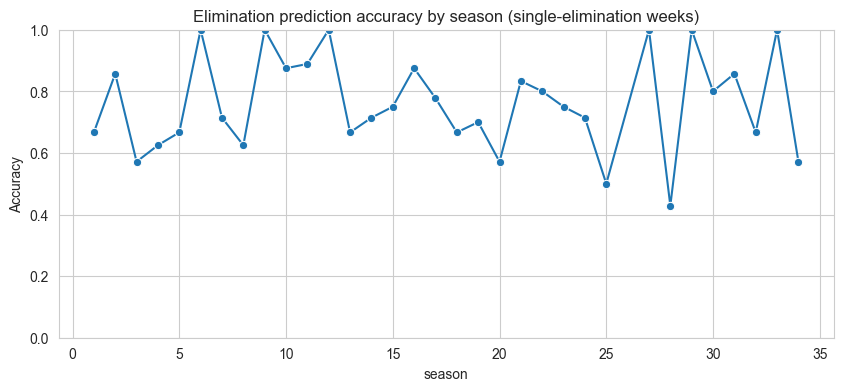

In [28]:
# 只看单淘汰周
truth = panel[panel["alive"] & panel["elim_this_week"]][["season","week","celebrity_name"]].rename(
    columns={"celebrity_name":"elim_true"}
)
elim_counts = truth.groupby(["season","week"]).size().rename("n_elim").reset_index()

eval_df = post.merge(truth, on=["season","week"], how="left").merge(elim_counts, on=["season","week"], how="left")
eval_df = eval_df[eval_df["n_elim"].eq(1)].copy()

eval_df["C_hat"] = eval_df["j_share"] + eval_df["p_mean"]
pred_week = eval_df.loc[eval_df.groupby(["season","week"])["C_hat"].idxmin(),
                        ["season","week","celebrity_name","elim_true"]]
pred_week["correct"] = pred_week["celebrity_name"].eq(pred_week["elim_true"])

acc_by_season = pred_week.groupby("season")["correct"].mean().reset_index()

plt.figure(figsize=(10,4))
sns.lineplot(data=acc_by_season, x="season", y="correct", marker="o")
plt.ylim(0,1)
plt.title("Elimination prediction accuracy by season (single-elimination weeks)")
plt.ylabel("Accuracy")
plt.show()

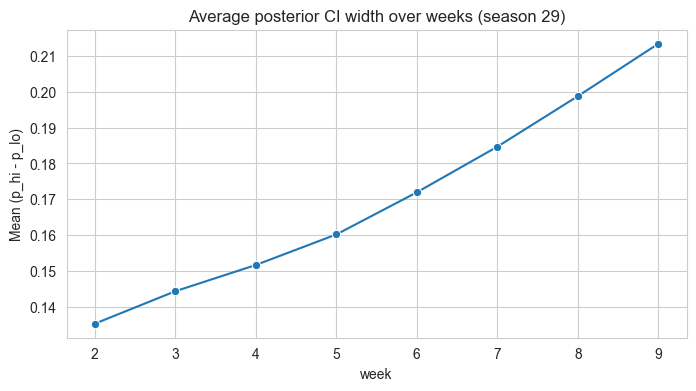

In [29]:
post_ci = post[post["has_ci"]].copy()
post_ci["ci_width"] = post_ci["p_hi"] - post_ci["p_lo"]

# 选择一个样例 season（CI 记录最多的）
s0 = post_ci.groupby("season").size().sort_values(ascending=False).index[0]
tmp = post_ci[post_ci["season"]==s0]

weekly_unc = tmp.groupby("week")["ci_width"].mean().reset_index()

plt.figure(figsize=(8,4))
sns.lineplot(data=weekly_unc, x="week", y="ci_width", marker="o")
plt.title(f"Average posterior CI width over weeks (season {s0})")
plt.ylabel("Mean (p_hi - p_lo)")
plt.show()

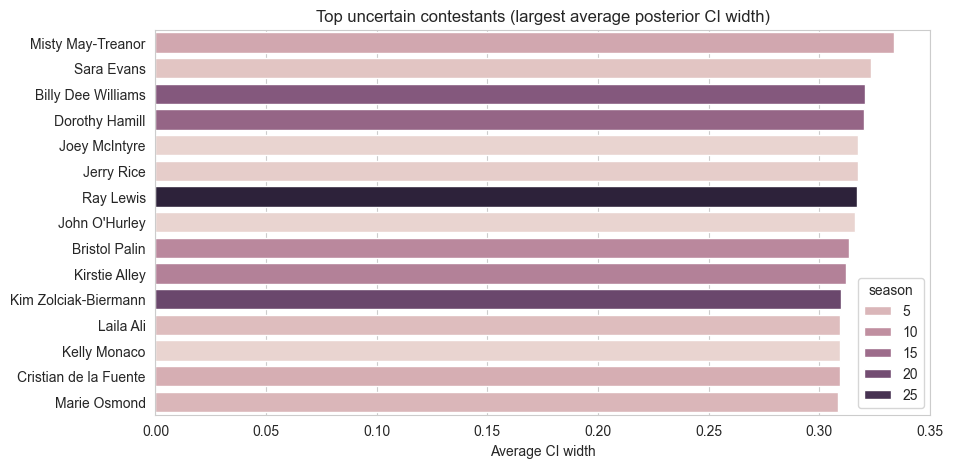

In [30]:
unc_by_player = (post_ci.groupby(["season","celebrity_name"])["ci_width"]
                 .mean().reset_index().sort_values("ci_width", ascending=False))

top = unc_by_player.head(15)

plt.figure(figsize=(10,5))
sns.barplot(data=top, x="ci_width", y="celebrity_name", hue="season", dodge=False)
plt.title("Top uncertain contestants (largest average posterior CI width)")
plt.xlabel("Average CI width")
plt.ylabel("")
plt.show()

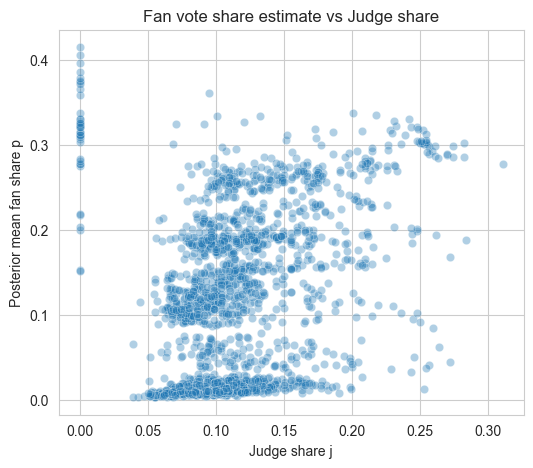

,season,week,celebrity_name,j_share,p_mean,p_lo,p_hi,gap
639,9,9,Tom DeLay,0.0,0.414838,0.251391,0.586986,0.414838
633,9,8,Tom DeLay,0.0,0.405247,0.237849,0.580452,0.405247
449,7,9,Misty May-Treanor,0.0,0.395872,0.233252,0.568052,0.395872
443,7,8,Misty May-Treanor,0.0,0.385406,0.224140,0.556863,0.385406
437,7,7,Misty May-Treanor,0.0,0.378343,0.215486,0.553740,0.378343
430,7,6,Misty May-Treanor,0.0,0.374825,0.211147,0.548880,0.374825
140,3,8,Sara Evans,0.0,0.373784,0.219728,0.539017,0.373784
421,7,5,Misty May-Treanor,0.0,0.371410,0.215521,0.547649,0.371410
411,7,4,Misty May-Treanor,0.0,0.365346,0.207835,0.536162,0.365346
134,3,7,Sara Evans,0.0,0.358388,0.201209,0.528769,0.358388


In [31]:
# 只看有CI的样本，避免混入纯先验周
tmp = post_ci.copy()

plt.figure(figsize=(6,5))
sns.scatterplot(data=tmp, x="j_share", y="p_mean", alpha=0.35)
plt.title("Fan vote share estimate vs Judge share")
plt.xlabel("Judge share j")
plt.ylabel("Posterior mean fan share p")
plt.show()

# 额外：找“p高但j低”的极端点（争议候选）
tmp["gap"] = tmp["p_mean"] - tmp["j_share"]
controversial = tmp.sort_values("gap", ascending=False).head(20)
controversial[["season","week","celebrity_name","j_share","p_mean","p_lo","p_hi","gap"]].head(20)

In [ ]:
# 观众评分(模型估计) vs 真实 result-judge 评分：散点/密度 + 拟合曲线 + 95% CI
plot_df = tmp[["j_share", "p_mean"]].dropna().copy()

# 轻微抖动，避免点重叠
rng = np.random.default_rng(42)
jitter = 0.002
plot_df["j_jit"] = plot_df["j_share"] + rng.normal(0, jitter, size=len(plot_df))
plot_df["p_jit"] = plot_df["p_mean"] + rng.normal(0, jitter, size=len(plot_df))

plt.figure(figsize=(7,6))

# 密度层（淡色背景）
sns.kdeplot(
    data=plot_df, x="j_share", y="p_mean",
    fill=True, levels=80, thresh=0.03, cmap="Blues", alpha=0.35
)

# 抖动散点
sns.scatterplot(
    data=plot_df, x="j_jit", y="p_jit",
    s=18, alpha=0.35, color="#2c3e50", edgecolor=None
)

# 拟合曲线（非线性）+ 95% CI
sns.regplot(
    data=plot_df, x="j_share", y="p_mean",
    order=2, ci=95, scatter=False,
    color="#e74c3c", line_kws={"linewidth":2.2}
)

plt.title("观众评分（模型估计） vs 真实 result-judge 评分")
plt.xlabel("真实 result-judge 评分")
plt.ylabel("模型估计的观众评分")
plt.tight_layout()
plt.show()

